# Regression of the lead times to the magnitude of errors by the nwp model
Since this scaling will happen inside the model, we need to calculate these factors based on the pre-processed data

In [ ]:
%load_ext autoreload
%autoreload 2
%autosave 30

In [ ]:
import hydra
import torch
from tqdm import tqdm

from genpp import BASE_DIR
from genpp.configs import register_resolvers
from genpp.models.layers import CropND
from einops import rearrange

try:
    register_resolvers()
except ValueError:
    pass

In [3]:
with hydra.initialize_config_dir(version_base=None, config_dir=str(BASE_DIR / "configs")):
    cfg = hydra.compose(config_name="base_fmunet")

datamodule = hydra.utils.instantiate(cfg.data.module)
datamodule.prepare_data()
datamodule.setup("fit")

train_dataloader = datamodule.train_dataloader()

Configuration hash: 05a2d862df574c3ec09a73a2516597b76945436332ad35785c3a5fe80dbc1c8c
Cached tensor data found. Verifying configuration...
Using cached tensor data.


In [ ]:
torch.set_float32_matmul_precision("highest")
# We need to crop the padded data back to the original size
crop = CropND(cfg.data.spatial.padding_list)

A = torch.zeros((2, 2, 2))
b = torch.zeros((2, 2))

for batch in tqdm(train_dataloader):
    # These are padded for the fm_unet -> this will downward bias the error -> remove the padding
    # This is done in the model.utils.LinearAbsTDScaling
    nwp_preds, obs, td = batch

    # Remove padding
    nwp_preds = crop(nwp_preds)
    obs = crop(obs)

    td = rearrange(td, "b -> b 1 1 1")
    td = td.expand_as(obs)
    td = rearrange(td, "b c h w -> c (b h w)")

    # The first 2 vars are temp_mean and wind_mean
    nwp_preds = rearrange(nwp_preds[:, :2, ...], "b c h w -> c (b h w)")
    obs = rearrange(obs, "b c h w -> c (b h w)")

    diff = (obs - nwp_preds).abs()

    ones = torch.ones_like(diff)

    X = torch.stack([ones, td], dim=1)
    y = diff

    # The rearrange is the same as calling the transpose on the last two dims if X
    A += torch.bmm(X, rearrange(X, "c a b -> c b a"))
    b += torch.bmm(X, y.unsqueeze(-1)).squeeze(-1)
betas = torch.linalg.solve(A, b)
print(betas)

100%|██████████| 171/171 [00:04<00:00, 41.61it/s]

tensor([[0.0849, 0.0996],
        [0.1960, 0.2184]])


In [131]:
allpreds = []
allobs = []
alltd = []
for batch in tqdm(train_dataloader):
    nwp_preds, obs, td = batch
    nwp_preds = crop(nwp_preds)
    obs = crop(obs)
    allpreds.append(nwp_preds)
    allobs.append(obs)
    alltd.append(td)
allobs = torch.cat(allobs)
allpreds = torch.cat(allpreds)[:, :2, ...]
alltd = rearrange(torch.cat(alltd), "b -> b 1 1 1")

100%|██████████| 171/171 [00:02<00:00, 76.32it/s]


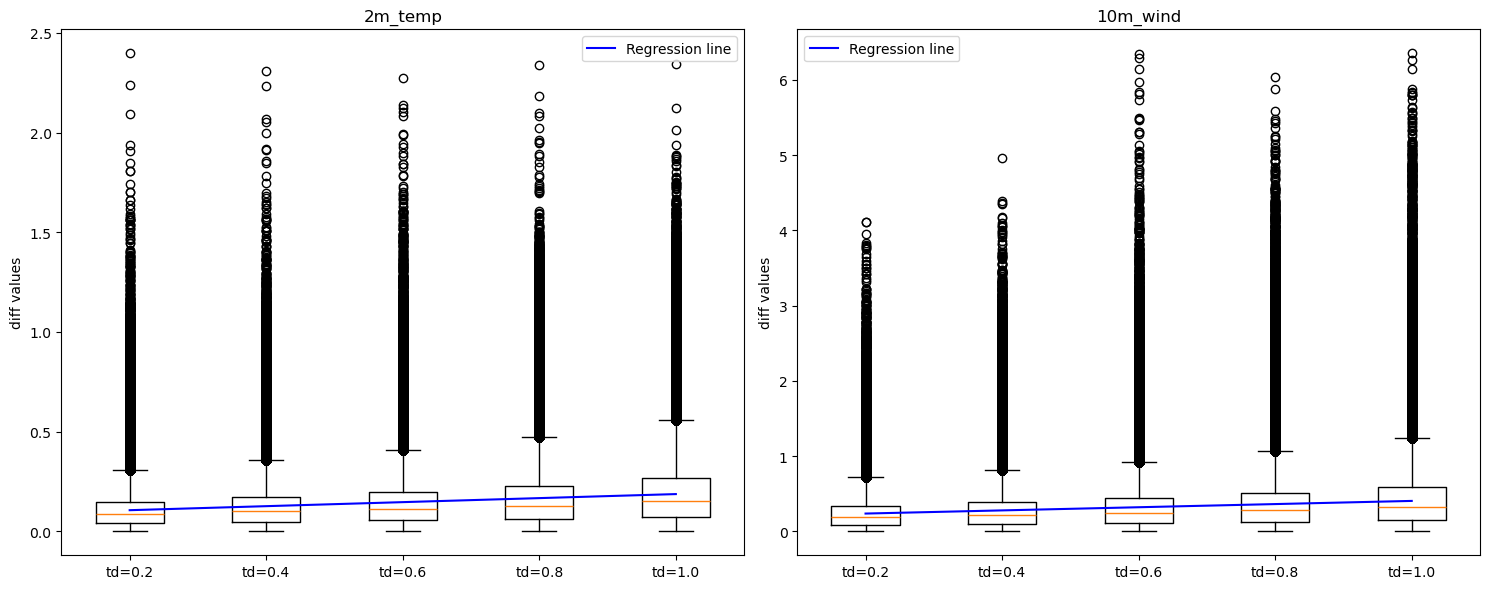

In [132]:
import matplotlib.pyplot as plt

# Flatten the tensors and create labels for coloring
diff = torch.abs(allobs - allpreds)  # type: ignore
td = alltd.expand_as(diff)  # type: ignore

diff = rearrange(diff, "b c h w -> c (b h w)")
td = rearrange(td, "b c h w -> c (b h w)")

# Create a boxplot instead of scatter plot since td has only 5 different values
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Get unique td values and sort them
unique_td_values = torch.unique(td)
sorted_td_vals = torch.sort(unique_td_values).values.numpy()

# Boxplot for dimension 0
for i, (d, td_c, ax, var) in enumerate(zip(diff, td, axes, ["2m_temp", "10m_wind"])):
    data_for_boxplot = []
    labels_for_boxplot = []
    for td_val in unique_td_values:
        mask = td_c == td_val
        if mask.sum() > 0:
            data_for_boxplot.append(d[mask].numpy())
            labels_for_boxplot.append(f"td={td_val.item():.1f}")

    ax.boxplot(data_for_boxplot, tick_labels=labels_for_boxplot)
    ax.set_title(var)
    ax.set_ylabel("diff values")

    # Add regression line at box positions
    intercept, slope = betas[i].numpy()
    x_positions = range(1, len(sorted_td_vals) + 1)
    y_positions = intercept + slope * sorted_td_vals
    ax.plot(x_positions, y_positions, "b-", label="Regression line")
    ax.legend()

plt.tight_layout()
plt.show()

## Lets look at the raw data first

In [17]:
import xarray as xr
from genpp.data import FORECAST_ENS_FLAT_AGG_PATH, OBSERVATIONS_FLAT_PATH

In [18]:
ens = xr.open_zarr(FORECAST_ENS_FLAT_AGG_PATH, consolidated=True)
obs = xr.open_zarr(OBSERVATIONS_FLAT_PATH, consolidated=True)

In [20]:
da = ens.to_dataarray(dim="feature")

In [106]:
import numpy as np
from tqdm import tqdm

betas = {}
for var in obs.data_vars:
    print(f"Processing {var}")
    A = np.zeros((2, 2))
    b_vec = np.zeros(2)
    for td in tqdm(ens.prediction_timedelta.values):
        td_hours = td / np.timedelta64(1, "h")
        target_times = ens.time + td
        mask = np.isin(target_times.values, obs.time.values)
        if mask.sum() == 0:
            continue
        pred = ens[var].sel(statistic="mean", prediction_timedelta=td).isel(time=mask)
        obs_at = obs[var].sel(time=target_times[mask])
        error = np.abs(pred - obs_at)
        error_flat = error.values.flatten()  # type:ignore
        ones = np.ones_like(error_flat)
        X = np.column_stack([ones, np.full_like(error_flat, td_hours)])
        A += X.T @ X
        b_vec += X.T @ error_flat
    beta = np.linalg.solve(A, b_vec)
    betas[var] = beta  # [intercept, slope]
print(betas)

Processing 10m_wind_speed


100%|██████████| 5/5 [00:03<00:00,  1.52it/s]


Processing 2m_temperature


100%|██████████| 5/5 [00:03<00:00,  1.56it/s]

{'10m_wind_speed': array([1.59894125e+00, 1.44680635e-03]), '2m_temperature': array([2.06442865, 0.01195041])}


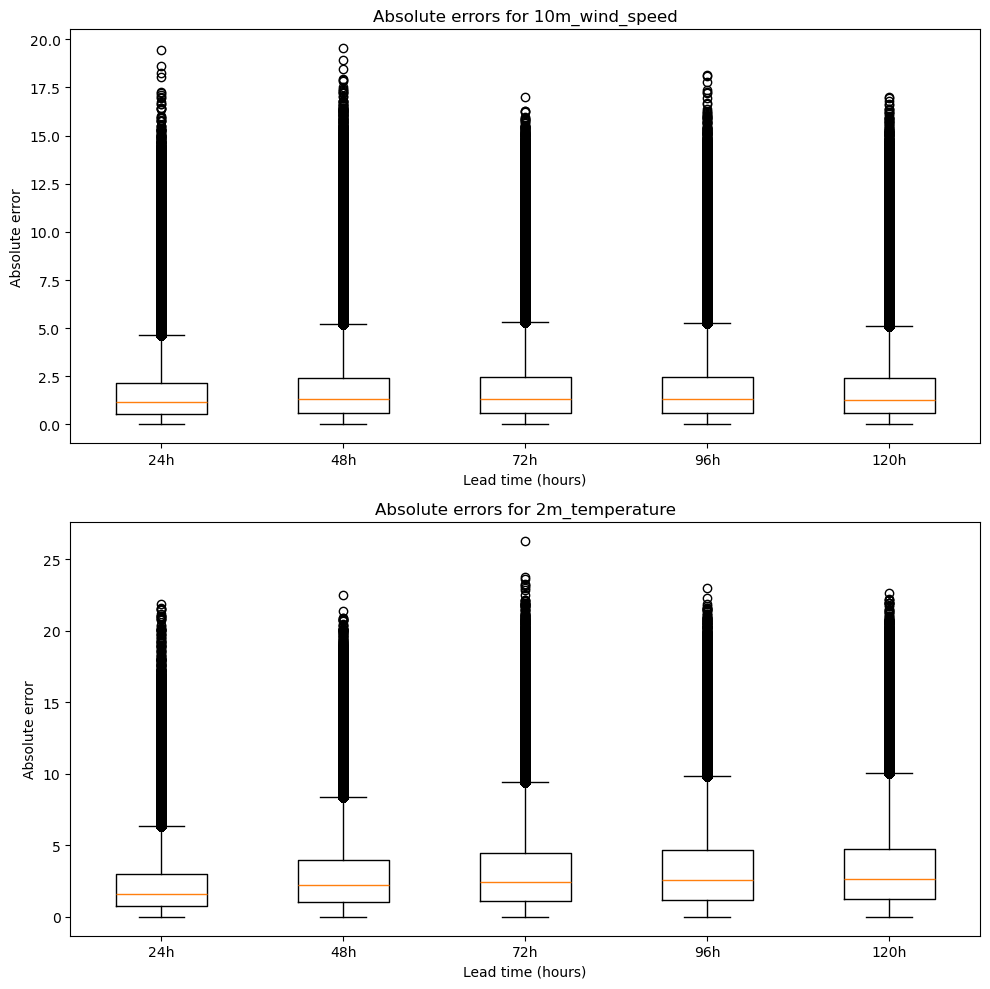

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(obs.data_vars), 1, figsize=(10, 5 * len(obs.data_vars)))

for i, var in enumerate(obs.data_vars):
    errors_per_td = []
    labels = []
    for td in ens.prediction_timedelta.values:
        td_hours = td / np.timedelta64(1, "h")
        target_times = ens.time + td
        mask = np.isin(target_times.values, obs.time.values)
        if mask.sum() == 0:
            continue
        pred = ens[var].sel(statistic="mean", prediction_timedelta=td).isel(time=mask)
        obs_at = obs[var].sel(time=target_times[mask])
        error = np.abs(pred - obs_at)
        error_flat = error.values.flatten()
        errors_per_td.append(error_flat)
        labels.append(f"{int(td_hours)}h")
    axes[i].boxplot(errors_per_td, tick_labels=labels)
    axes[i].set_title(f"Absolute errors for {var}")
    axes[i].set_xlabel("Lead time (hours)")
    axes[i].set_ylabel("Absolute error")

plt.tight_layout()
plt.show()